In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

In [2]:
# Environment configuration
GRID_SIZE = 8                 # 8x8 city grid
STATION_POS = (0, 0)          # charging station location
N_PACKAGES = 3                # fixed number of packages per episode
MAX_BATTERY = 60.0
BATTERY_SCALE = 100.0         # fixed scale for the battery observation
BASE_MOVE_COST = 2.0          # battery cost per move with no wind
WIND_EFFECT = 1.5             # how much wind changes the move cost
WIND_SIGMA = 0.15             # random walk noise for wind evolution
CHARGE_RATE = 25.0            # battery recovered per recharge action
MAX_STEPS = 200
DEADLINE_RANGE = (20, 50)     # min/max initial deadline (in steps)

# Actions
ACTIONS = {
    0: "north", 1: "south", 2: "east", 3: "west", 4: "pickup", 5: "deliver", 6: "recharge", 7: "wait",
}
MOVES = {0: (0, 1), 1: (0, -1), 2: (1, 0), 3: (-1, 0)}

In [3]:
WIND_PERSISTENCE = 0.9

def next_wind(wind, rng):
    noise = rng.normal(0.0, WIND_SIGMA, size=2)
    new_wind = WIND_PERSISTENCE * wind + noise
    return np.clip(new_wind, -1.0, 1.0)

def move_cost(direction, wind):
    aligment = np.dot(direction, wind) # +1 tailwind, -1 headwind
    return BASE_MOVE_COST - WIND_EFFECT * aligment

### Demonstração da dinâmica do vento

A célula abaixo simula alguns passos com um vento inicial soprando para o leste, mostrando dois comportamentos da transição do MDP:

- o vento evolui de forma gradual (random walk correlacionado), mantendo parte do valor anterior a cada passo;
- o custo de bateria depende da direção do movimento em relação ao vento: mover a favor (leste) custa menos que mover contra (oeste).

In [4]:
rng = np.random.default_rng(42)
wind = np.array([0.5, 0.0])  # wind blowing east

for t in range(5):
    east = move_cost(np.array(MOVES[2]), wind)
    west = move_cost(np.array(MOVES[3]), wind)
    print(f"t={t} wind={wind.round(2)} cost_east={east:.2f} cost_west={west:.2f}")
    wind = next_wind(wind, rng)

t=0 wind=[0.5 0. ] cost_east=1.25 cost_west=2.75
t=1 wind=[ 0.5  -0.16] cost_east=1.26 cost_west=2.74
t=2 wind=[0.56 0.  ] cost_east=1.16 cost_west=2.84
t=3 wind=[ 0.21 -0.19] cost_east=1.68 cost_west=2.32
t=4 wind=[ 0.21 -0.22] cost_east=1.69 cost_west=2.31


In [5]:
# Package status codes
WAITING, CARRIED, DONE = 0, 1, 2
LATE_WINDOW = 15 # steps after the deadline before a package expires

# Rewards
DELIVERY_REWARD = 10.0
LATE_FACTOR = 0.5        # late delivery gets at most half the reward, decaying to zero
EXPIRE_PENALTY = -5.0
STEP_PENALTY = -0.1
CRASH_PENALTY = -50.0
INVALID_PENALTY = -0.5   # pickup/deliver/recharge/move not allowed in the current state
HOVER_COST = 0.5         # battery spent when waiting outside the station

# Reward shaping
PICKUP_REWARD = 2.0      # bonus for picking up a package
SHAPING_WEIGHT = 0.5     # scale of the distance-based potential
SHAPING_GAMMA = 1.0      # must match the algorithm's gamma
STAGE_VALUE = 2 * (GRID_SIZE - 1) # max Manhattan distance: completing a stage always raises the potential

class DroneDeliveryEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, render_mode=None, reward_shaping=True, max_battery=MAX_BATTERY):
        super().__init__()
        self.render_mode = render_mode
        self.reward_shaping = reward_shaping
        self.max_battery = max_battery

        # 8 discrete actions: 4 moves, pickup, deliver, recharge, wait
        self.action_space = spaces.Discrete(len(ACTIONS))

        # + relative vector to current target (2) + relative vector to station (2)
        obs_size = 2 + 1 + 2 + 2 + 4 + N_PACKAGES * 8
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32)

    def _norm_pos(self, pos):
        return np.array(pos, dtype=np.float32) / (GRID_SIZE - 1)

    def _get_obs(self):
        target = self._current_target() or self.drone_pos
        rel_target = (np.array(target) - np.array(self.drone_pos)) / (GRID_SIZE - 1)
        rel_station = (np.array(STATION_POS) - np.array(self.drone_pos)) / (GRID_SIZE - 1)

        parts = [
            self._norm_pos(self.drone_pos),
            [self.battery / BATTERY_SCALE],
            self.wind,
            self.prev_wind,
            rel_target,
            rel_station,
        ]
        
        for pkg in self.packages:
            status_one_hot = np.zeros(3, dtype=np.float32)
            status_one_hot[pkg["status"]] = 1.0
            deadline = np.clip(pkg["deadline"] / DEADLINE_RANGE[1], -1.0, 1.0)
            parts += [
                self._norm_pos(pkg["pickup"]),
                self._norm_pos(pkg["dest"]),
                [deadline],
                status_one_hot,
            ]
        return np.concatenate(parts).astype(np.float32)

    def _random_cell(self):
        while True:
            cell = tuple(int(v) for v in self.np_random.integers(0, GRID_SIZE, size=2))
            if cell != STATION_POS:
                return cell

    def _random_package(self):
        pickup = self._random_cell()
        dest = self._random_cell()
        while dest == pickup:
            dest = self._random_cell()
        deadline = int(self.np_random.integers(DEADLINE_RANGE[0], DEADLINE_RANGE[1] + 1))
        return {"pickup": pickup, "dest": dest, "deadline": deadline, "status": WAITING}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0
        self.drone_pos = STATION_POS
        self.battery = self.max_battery
        self.wind = self.np_random.uniform(-0.5, 0.5, size=2)
        self.prev_wind = self.wind.copy()
        self.packages = [self._random_package() for _ in range(N_PACKAGES)]
        self.stats = {"on_time": 0, "late": 0, "expired": 0, "crashed": False}
        self._last_potential = self._potential()
        return self._get_obs(), {}

    def _carried_package(self):
        for pkg in self.packages:
            if pkg["status"] == CARRIED:
                return pkg
        return None

    def _current_target(self):
        carried = self._carried_package()
        if carried is not None:
            return carried["dest"]
        x, y = self.drone_pos
        waiting = [p["pickup"] for p in self.packages if p["status"] == WAITING]
        if not waiting:
            return None
        return min(waiting, key=lambda c: abs(c[0] - x) + abs(c[1] - y))

    def _potential(self):
        carried = sum(p["status"] == CARRIED for p in self.packages)
        delivered = self.stats["on_time"] + self.stats["late"]
        progress = carried + 2 * delivered

        target = self._current_target()
        dist = 0
        if target is not None:
            x, y = self.drone_pos
            dist = abs(target[0] - x) + abs(target[1] - y)
        return SHAPING_WEIGHT * (STAGE_VALUE * progress - dist)

    def _apply_move(self, action):
        dx, dy = MOVES[action]
        new_x, new_y = self.drone_pos[0] + dx, self.drone_pos[1] + dy
        if not (0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE):
            return INVALID_PENALTY  # hit the grid border, stays in place
        self.battery -= move_cost(np.array([dx, dy]), self.wind)
        self.drone_pos = (new_x, new_y)
        return 0.0

    def _apply_pickup(self):
        if self._carried_package() is not None:
            return INVALID_PENALTY
        for pkg in self.packages:
            if pkg["status"] == WAITING and pkg["pickup"] == self.drone_pos:
                pkg["status"] = CARRIED
                return 0.0
        return INVALID_PENALTY

    def _apply_deliver(self):
        pkg = self._carried_package()
        if pkg is None or pkg["dest"] != self.drone_pos:
            return INVALID_PENALTY
        pkg["status"] = DONE
        if pkg["deadline"] >= 0:
            self.stats["on_time"] += 1
            return DELIVERY_REWARD
        self.stats["late"] += 1
        lateness = -pkg["deadline"]
        return DELIVERY_REWARD * LATE_FACTOR * (1 - lateness / LATE_WINDOW)

    def _apply_recharge(self):
        if self.drone_pos != STATION_POS:
            return INVALID_PENALTY
        self.battery = min(self.max_battery, self.battery + CHARGE_RATE)
        return 0.0

    def step(self, action):
        action = int(action)
        self.steps += 1
        reward = STEP_PENALTY

        if action in MOVES:
            reward += self._apply_move(action)
        elif action == 4:
            reward += self._apply_pickup()
        elif action == 5:
            reward += self._apply_deliver()
        elif action == 6:
            reward += self._apply_recharge()
        elif action == 7 and self.drone_pos != STATION_POS:
            self.battery -= HOVER_COST

        # Wind evolves after the action
        self.prev_wind = self.wind
        self.wind = next_wind(self.wind, self.np_random)

        # Deadlines tick down; packages that are too late expire
        for pkg in self.packages:
            if pkg["status"] != DONE:
                pkg["deadline"] -= 1
                if pkg["deadline"] < -LATE_WINDOW:
                    pkg["status"] = DONE
                    self.stats["expired"] += 1
                    reward += EXPIRE_PENALTY

        terminated = False
        if self.battery <= 0 and self.drone_pos != STATION_POS:
            reward += CRASH_PENALTY
            self.stats["crashed"] = True
            terminated = True
        elif all(pkg["status"] == DONE for pkg in self.packages):
            terminated = True
        self.battery = max(self.battery, 0.0)

        if self.reward_shaping:
            new_potential = self._potential()
            reward += SHAPING_GAMMA * new_potential - self._last_potential
            self._last_potential = new_potential

        truncated = self.steps >= MAX_STEPS
        return self._get_obs(), reward, terminated, truncated, dict(self.stats)

    def _draw(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, GRID_SIZE - 0.5)
        ax.set_ylim(-0.5, GRID_SIZE - 0.5)
        ax.set_xticks(range(GRID_SIZE))
        ax.set_yticks(range(GRID_SIZE))
        ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        ax.grid(which="minor", color="lightgray")
        ax.set_aspect("equal")

        # Wind field (same wind in every cell)
        xs, ys = np.meshgrid(range(GRID_SIZE), range(GRID_SIZE))
        ax.quiver(xs, ys, np.full_like(xs, self.wind[0], dtype=float), np.full_like(ys, self.wind[1], dtype=float), color="gray", alpha=0.3, scale=12)

        # Charging station
        sx, sy = STATION_POS
        ax.add_patch(plt.Rectangle((sx - 0.5, sy - 0.5), 1, 1, color="lightgreen"))
        ax.text(sx, sy - 0.35, "station", ha="center", fontsize=7)

        # Packages: square = pickup, X = destination, label = id:deadline
        dest_labels = {}
        for i, pkg in enumerate(self.packages):
            if pkg["status"] == DONE:
                continue
            if pkg["status"] == WAITING:
                px, py = pkg["pickup"]
                ax.plot(px, py, marker="s", color="tab:brown", markersize=14)
                ax.text(px, py, str(i), ha="center", va="center", color="white", fontsize=8)
            dest_labels.setdefault(pkg["dest"], []).append(f"{i}:{pkg['deadline']}")

        for (dx, dy), labels in dest_labels.items():
            ax.plot(dx, dy, marker="X", color="tab:red", markersize=12)
            ax.text(dx + 0.25, dy + 0.25, " ".join(labels), fontsize=8)

        # Drone (with a small square if carrying a package)
        x, y = self.drone_pos
        ax.plot(x, y, marker="o", color="tab:blue", markersize=18)
        if self._carried_package() is not None:
            ax.plot(x, y, marker="s", color="tab:brown", markersize=7)

        ax.set_title(
            f"Step {self.steps} | Battery {self.battery:.0f}% | Wind ({self.wind[0]:+.2f}, {self.wind[1]:+.2f})"
        )
        return fig

    def render(self):
        fig = self._draw()
        if self.render_mode == "rgb_array":
            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
            plt.close(fig)
            return frame
        plt.show()

In [ ]:
env = DroneDeliveryEnv()
print(env.action_space)
print(env.observation_space.shape)

In [ ]:
env = DroneDeliveryEnv()
obs, info = env.reset(seed=0)
print(obs.shape)
print(env.observation_space.contains(obs))
for pkg in env.packages:
    print(pkg)

In [6]:
from gymnasium.utils.env_checker import check_env

env = DroneDeliveryEnv()
check_env(env)

obs, info = env.reset(seed=0)
total_reward, done = 0.0, False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"steps={env.steps} total_reward={total_reward:.2f} battery={env.battery:.1f}")
print(info)

steps=58 total_reward=-34.30 battery=10.1
{'on_time': 0, 'late': 0, 'expired': 3, 'crashed': False}


/Users/i753841/Documents/pos-graduacao-IA/aprendizado-por-reforco/.venv/lib/python3.14/site-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [ ]:
env = DroneDeliveryEnv(render_mode="human")
env.reset(seed=0)
env.render()

for action in [2, 2, 0]:  # east, east, north
    env.step(action)
env.render()

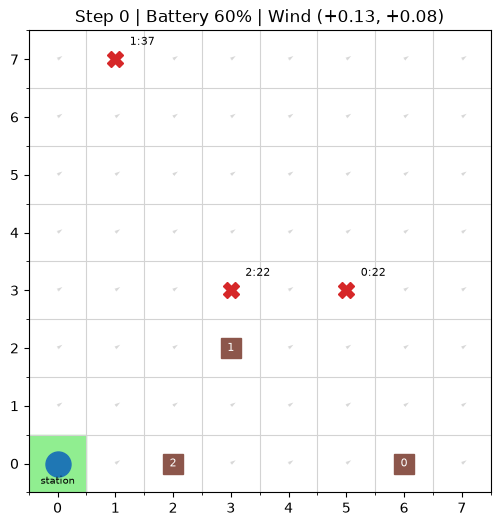

(35,) (600, 600, 3)


In [7]:
gym.register(
    id="DroneDelivery-v0",
    entry_point=DroneDeliveryEnv,
)

env = gym.make("DroneDelivery-v0", render_mode="rgb_array")
check_env(env.unwrapped)

obs, info = env.reset(seed=0)
frame = env.render()
print(obs.shape, frame.shape)

In [ ]:
def evaluate_random(n_episodes=20, seed=0):
    env = gym.make("DroneDelivery-v0")
    rewards = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
            total += reward
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

rand_mean, rand_std = evaluate_random()
print(f"Random baseline: {rand_mean:.2f} +/- {rand_std:.2f}")

### Treino

In [9]:
import time
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

In [ ]:
from stable_baselines3.common.monitor import Monitor

train_env = make_vec_env("DroneDelivery-v0", n_envs=4, seed=0)

start = time.time()
model = PPO("MlpPolicy", train_env, seed=0, device="cpu", verbose=0, ent_coef=0.01)
model.learn(total_timesteps=300_000, progress_bar=False)
print(f"{time.time() - start:.1f}s")

eval_env = Monitor(gym.make("DroneDelivery-v0"))
mean, std = evaluate_policy(model, eval_env, n_eval_episodes=20)
print(f"PPO (default): {mean:.2f} +/- {std:.2f}")

In [ ]:
eval_env = gym.make("DroneDelivery-v0")
obs, info = eval_env.reset(seed=0)
actions, done = [], False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    actions.append(ACTIONS[int(action)])
    done = terminated or truncated

from collections import Counter
print(Counter(actions))
print(info, "final position:", eval_env.unwrapped.drone_pos)

In [ ]:
env = gym.make("DroneDelivery-v0")
print("shaping:", env.unwrapped.reward_shaping)
obs, _ = env.reset(seed=0)
_, r_east, *_ = env.step(2)   # east, toward package 0 at (2, 0)
_, r_wait, *_ = env.step(7)   # wait
print(f"reward east={r_east:.3f} wait={r_wait:.3f}")

In [11]:
def evaluate_agent(model, n_episodes=20, deterministic=True, seed=1000):
    env = gym.make("DroneDelivery-v0")
    rewards, on_time, late, expired, crashes = [], [], [], [], []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            total += reward
            done = terminated or truncated
        rewards.append(total)
        on_time.append(info["on_time"])
        late.append(info["late"])
        expired.append(info["expired"])
        crashes.append(info["crashed"])
    return {
        "reward_mean": np.mean(rewards),
        "reward_std": np.std(rewards),
        "on_time_mean": np.mean(on_time),
        "late_mean": np.mean(late),
        "expired_mean": np.mean(expired),
        "crash_rate": np.mean(crashes),
    }

In [16]:
def greedy_action(env):
    e = env.unwrapped
    x, y = e.drone_pos
    dist_station = abs(x - STATION_POS[0]) + abs(y - STATION_POS[1])

    # At the station with battery not full: recharge
    if e.drone_pos == STATION_POS and e.battery < e.max_battery - CHARGE_RATE:
        return 6
    # Battery too low to be safe: head back to the station
    if e.battery < dist_station * (BASE_MOVE_COST + WIND_EFFECT) + 10:
        tx, ty = STATION_POS
    else:
        target = e._current_target()
        if target is None:
            return 7
        if e.drone_pos == target:
            return 5 if e._carried_package() is not None else 4
        tx, ty = target

    if tx > x: return 2  # east
    if tx < x: return 3  # west
    if ty > y: return 0  # north
    return 1             # south

env = gym.make("DroneDelivery-v0")
results, totals = [], []
for ep in range(20):
    obs, info = env.reset(seed=1000 + ep)
    done, total = False, 0.0
    while not done:
        obs, reward, terminated, truncated, info = env.step(greedy_action(env))
        total += reward
        done = terminated or truncated
    results.append(info)
    totals.append(total)

print(f"reward {np.mean(totals):.1f}")
for key in ["on_time", "late", "expired", "crashed"]:
    print(key, np.mean([r[key] for r in results]))

reward 2.7
on_time 0.7
late 0.05
expired 2.25
crashed 0.0


In [14]:
env = gym.make("DroneDelivery-v0")

def run_policy(policy_fn, seed):
    obs, _ = env.reset(seed=seed)
    total, done = 0.0, False
    while not done:
        obs, r, terminated, truncated, info = env.step(policy_fn(env))
        total += r
        done = terminated or truncated
    return total

# 1) Reward check: greedy should score far above always-wait
for name, fn in [("wait", lambda e: 7), ("greedy", greedy_action)]:
    totals = [run_policy(fn, 1000 + i) for i in range(20)]
    print(f"{name}: {np.mean(totals):.2f}")

# 2) Observation check: relative target in obs must match the real target
obs, _ = env.reset(seed=0)
print("drone", env.unwrapped.drone_pos, "target", env.unwrapped._current_target())
print("rel_target in obs:", obs[7:9] * (GRID_SIZE - 1))

wait: -18.85
greedy: 2.66
drone (0, 0) target (2, 0)
rel_target in obs: [2. 0.]


In [ ]:
train_env = make_vec_env("DroneDelivery-v0", n_envs=4, seed=0)
model = PPO("MlpPolicy", train_env, seed=0, device="cpu", verbose=0, ent_coef=0.01)

for block in range(10):
    model.learn(total_timesteps=200_000, reset_num_timesteps=False, progress_bar=False)
    res = evaluate_agent(model, deterministic=False)
    print(f"{(block + 1) * 200}k | reward={res['reward_mean']:.1f} "
          f"on_time={res['on_time_mean']:.2f} late={res['late_mean']:.2f} "
          f"expired={res['expired_mean']:.2f} crash={res['crash_rate']:.2f}")

In [15]:
env = gym.make("DroneDelivery-v0")
recharges, min_battery = [], []
for ep in range(20):
    obs, _ = env.reset(seed=1000 + ep)
    done, n_recharge, low = False, 0, MAX_BATTERY
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        n_recharge += int(action) == 6
        obs, r, terminated, truncated, info = env.step(action)
        low = min(low, env.unwrapped.battery)
        done = terminated or truncated
    recharges.append(n_recharge)
    min_battery.append(low)

print(f"recharges per episode: {np.mean(recharges):.2f}")
print(f"min battery per episode: {np.mean(min_battery):.1f}%")

recharges per episode: 1.05
min battery per episode: 6.5%


In [12]:
def train_blocks(model, n_blocks, label):
    for block in range(n_blocks):
        model.learn(total_timesteps=200_000, reset_num_timesteps=False, progress_bar=False)
        res = evaluate_agent(model, deterministic=False)
        print(f"{label} {(block + 1) * 200}k | reward={res['reward_mean']:.1f} "
              f"on_time={res['on_time_mean']:.2f} late={res['late_mean']:.2f} "
              f"expired={res['expired_mean']:.2f} crash={res['crash_rate']:.2f}")

# Stage 1: generous battery, the agent learns to deliver
stage1_env = make_vec_env("DroneDelivery-v0", n_envs=4, seed=0, env_kwargs={"max_battery": 100.0})
model = PPO("MlpPolicy", stage1_env, seed=0, device="cpu", verbose=0, ent_coef=0.01)
train_blocks(model, 5, "stage1")

# Stage 2: real battery, the agent learns to manage recharging
stage2_env = make_vec_env("DroneDelivery-v0", n_envs=4, seed=0, env_kwargs={"max_battery": MAX_BATTERY})
model.set_env(stage2_env)
train_blocks(model, 5, "stage2")

stage1 200k | reward=-53.7 on_time=0.00 late=0.00 expired=1.50 crash=0.85
stage1 400k | reward=-48.3 on_time=0.00 late=0.00 expired=1.90 crash=0.70
stage1 600k | reward=-33.0 on_time=0.00 late=0.00 expired=2.70 crash=0.30
stage1 800k | reward=-36.5 on_time=0.55 late=0.00 expired=0.90 crash=0.90
stage1 1000k | reward=28.1 on_time=2.05 late=0.40 expired=0.05 crash=0.55
stage2 200k | reward=38.0 on_time=2.25 late=0.30 expired=0.05 crash=0.40
stage2 400k | reward=35.7 on_time=2.20 late=0.35 expired=0.00 crash=0.45
stage2 600k | reward=35.2 on_time=2.15 late=0.40 expired=0.00 crash=0.45
stage2 800k | reward=37.1 on_time=2.15 late=0.40 expired=0.05 crash=0.40
stage2 1000k | reward=37.3 on_time=2.15 late=0.40 expired=0.05 crash=0.40
